In [20]:
# Assignment Module 5
# --- Q4. NLP and Sequence Modeling Mini Project — Graded Assessment ---

In [21]:
!mkdir ../data
# Now upload the datasets provided

--- TASK 1: DATASET EXPLORATION ---

Total Records: 1500

FIRST 5 RECORDS:


,ticket_id,channel,customer_message,sentiment_label,word_count,urgent_flag
0,TKT00001,chat,I need information about the payment process. ...,neutral,18,1
1,TKT00002,phone,I need information about the payment process.,neutral,7,0
2,TKT00003,email,The refund process was fast and convenient. I ...,positive,12,0
3,TKT00004,social,My refund is still pending and this experience...,negative,15,1
4,TKT00005,chat,Please tell me how to update my account details.,neutral,9,0



DATASET INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   ticket_id         1500 non-null   object
 1   channel           1500 non-null   object
 2   customer_message  1500 non-null   object
 3   sentiment_label   1500 non-null   object
 4   word_count        1500 non-null   int64 
 5   urgent_flag       1500 non-null   int64 
dtypes: int64(2), object(4)
memory usage: 70.4+ KB
None

TARGET COLUMN: sentiment_label

Target Labels: ['neutral' 'positive' 'negative']

Average Word Count: 12.72

Class Distribution:
sentiment_label
neutral     524
negative    497
positive    479
Name: count, dtype: int64


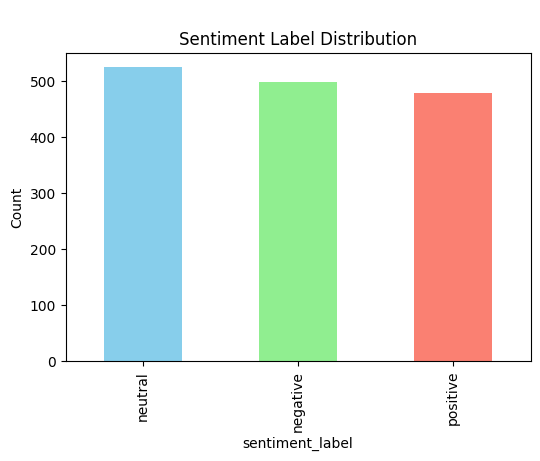


Sample Records:
                                    customer_message sentiment_label
0  I need information about the payment process. ...         neutral
1      I need information about the payment process.         neutral
2  The refund process was fast and convenient. I ...        positive


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

# ---------------------------------------------------------
# TASK 1: Dataset Understanding
# ---------------------------------------------------------
print("--- TASK 1: DATASET EXPLORATION ---\n")

# Load Dataset
df = pd.read_csv('/data/customer_support_text_classification.csv')

print(f"Total Records: {len(df)}")
print("\nFIRST 5 RECORDS:")
display(df.head())
print("\nDATASET INFO:")
print(df.info())

target_column = df.columns[3]
print("\nTARGET COLUMN:", target_column)
print(f"\nTarget Labels: {df['sentiment_label'].unique()}")
print(f"\nAverage Word Count: {df['word_count'].mean():.2f}")

# Class distribution
print("\nClass Distribution:")
class_counts = df['sentiment_label'].value_counts()
print(class_counts)

# Plot Class distribution
plt.figure(figsize=(6,4))
class_counts.plot(kind='bar', color=['skyblue', 'lightgreen', 'salmon'])
plt.title("\nSentiment Label Distribution")
plt.ylabel("Count")
plt.show()

print("\nSample Records:")
print(df[['customer_message', 'sentiment_label']].head(3))

In [23]:
from sklearn.model_selection import train_test_split

# ---------------------------------------------------------
# TASK 2: Text Preprocessing
# ---------------------------------------------------------
print("--- TASK 2: PREPROCESSING ---\n")

def clean_text(text):
    # Lowercase
    text = text.lower()
    # Remove special characters and numbers (keep only letters)
    text = re.sub(r'[^a-z\s]', '', text)
    return text

# Apply cleaning
df['cleaned_text'] = df['customer_message'].apply(clean_text)

# Encode Labels (positive=2, neutral=1, negative=0)
encoder = LabelEncoder()
df['encoded_label'] = encoder.fit_transform(df['sentiment_label'])

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(df['cleaned_text'], df['encoded_label'], test_size=0.2, random_state=42)
print("Data split into training and testing sets.")

--- TASK 2: PREPROCESSING ---

Data split into training and testing sets.


In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, accuracy_score

# ---------------------------------------------------------
# TASK 3 & 4: Baseline Model (TF-IDF + Naive Bayes)
# ---------------------------------------------------------
print("--- TASK 3 & 4: BASELINE MODEL (TF-IDF + Naive Bayes) ---\n")

# Vectorize using TF-IDF
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Train Baseline Model
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

# Predict and Evaluate
nb_preds = nb_model.predict(X_test_tfidf)
print(f"Baseline Accuracy: {accuracy_score(y_test, nb_preds):.4f}\n")
print("Baseline Classification Report:")
print(classification_report(y_test, nb_preds, target_names=encoder.classes_))

--- TASK 3 & 4: BASELINE MODEL (TF-IDF + Naive Bayes) ---

Baseline Accuracy: 1.0000

Baseline Classification Report:
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00       109
     neutral       1.00      1.00      1.00       104
    positive       1.00      1.00      1.00        87

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300




--- TASK 5: SEQUENCE MODEL (LSTM) ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_14 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_10            │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_14 (LSTM)                  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Training LSTM Model...
Epoch 1/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 84ms/step - accuracy: 0.3342 - loss: 1.1007 - val_accuracy: 0.3467 - val_loss: 1.0955
Epoch 2/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 115ms/step - accuracy: 0.3458 - loss: 1.0993 - val_accuracy: 0.3467 - val_loss: 1.0972
Epoch 3/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - accuracy: 0.5175 - loss: 0.8950 - val_accuracy: 0.7100 - val_loss: 0.4697
Epoch 4/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - accuracy: 0.6850 - loss: 0.4910 - val_accuracy: 0.6367 - val_loss: 0.4591
Epoch 5/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - accuracy: 0.6783 - loss: 0.4654 - val_accuracy: 0.6367 - val_loss: 0.4692
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6367 - loss: 0.4692

LSTM Test Accuracy: 0.6367


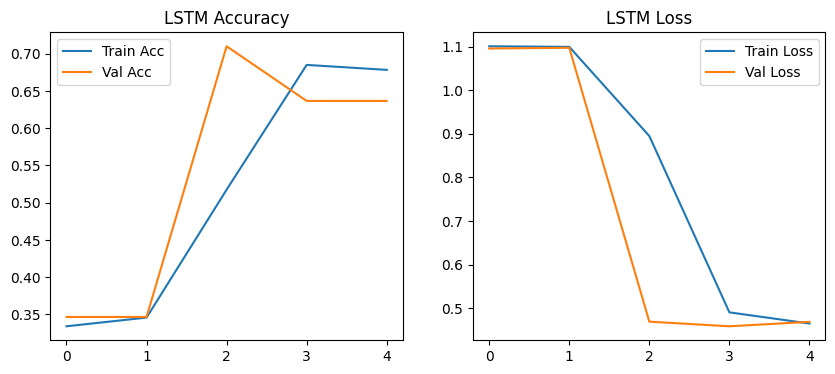


--- SAMPLE PREDICTIONS ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 435ms/step
Text: 'I am very unhappy with the delayed service.' -> Predicted Sentiment: positive
Text: 'The refund process was fast and convenient.' -> Predicted Sentiment: positive
Text: 'I need information about my account.' -> Predicted Sentiment: neutral


In [25]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import LabelEncoder

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, SpatialDropout1D

# ---------------------------------------------------------
# TASK 5: Sequence Model (LSTM)
# ---------------------------------------------------------
print("\n--- TASK 5: SEQUENCE MODEL (LSTM) ---")

# Sequence Model Parameters
MAX_WORDS = 5000 # Vocabulary size
MAX_LEN = 50     # Sequence length padding

# Tokenize and sequence
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Pad sequences
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post', truncating='post')

# Build LSTM Architecture
lstm_model = Sequential([
    Embedding(input_dim=MAX_WORDS, output_dim=64, input_length=MAX_LEN),
    SpatialDropout1D(0.2), # Helps prevent overfitting in embeddings
    LSTM(64, dropout=0.2, recurrent_dropout=0.2),
    Dense(3, activation='softmax') # 3 classes for sentiments
])

lstm_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
lstm_model.summary()

# Train the Model
print("Training LSTM Model...")
history = lstm_model.fit(
    X_train_pad, y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_test_pad, y_test),
    verbose=1
)

# Evaluate
lstm_loss, lstm_acc = lstm_model.evaluate(X_test_pad, y_test)
print(f"\nLSTM Test Accuracy: {lstm_acc:.4f}")

# Plot Training History (Save to results/)
plt.figure(figsize=(10,4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title('LSTM Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('LSTM Loss')
plt.savefig('model_evaluation.png') # Expected in Repository
plt.show()

# Sample Predictions
print("\n--- SAMPLE PREDICTIONS ---")
sample_texts = [
    "I am very unhappy with the delayed service.",
    "The refund process was fast and convenient.",
    "I need information about my account."
]

sample_seqs = pad_sequences(tokenizer.texts_to_sequences(sample_texts), maxlen=MAX_LEN, padding='post')
predictions = lstm_model.predict(sample_seqs)

# Decode predictions
predicted_labels = encoder.inverse_transform(np.argmax(predictions, axis=1))

# Save predictions to file (Expected in Repository)
with open('sample_predictions.txt', 'w') as f:
    for text, label in zip(sample_texts, predicted_labels):
        output = f"Text: '{text}' -> Predicted Sentiment: {label}\n"
        print(output.strip())
        f.write(output)